# Clinical Trials EDA
Exploratory analysis of cleaned studies from `clinical_trials.db`.

In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from query import load_all

df = load_all()
print(f"{len(df):,} studies loaded")
df.head(3)

2,172 studies loaded


,nct_id,title,status,phase,study_type,start_date,completion_date,sponsor,sponsor_class,conditions,...,interventions,arm_groups,enrollment,enrollment_type,masking,allocation,intervention_model,primary_purpose,locations,ingested_at
0,NCT04909034,"A Randomized, Placebo Controlled Study to Eval...",COMPLETED,NA,INTERVENTIONAL,2021-08-20,2024-11-30,Microbio Co Ltd,INDUSTRY,"[""NSCLC Stage IIIB~IV""]",...,"[{""type"": ""DRUG"", ""name"": ""MS-20"", ""descriptio...","[{""label"": ""MS-20 oral solution"", ""type"": ""EXP...",15.0,ACTUAL,QUADRUPLE,RANDOMIZED,PARALLEL,TREATMENT,"[{""facility"": ""Kaohsiung Medical University Ch...",2026-05-07T19:09:57.261654+00:00
1,NCT05184712,Phase 3 Clinical Study of AK112 for NSCLC Pati...,ACTIVE_NOT_RECRUITING,PHASE3,INTERVENTIONAL,2022-01-25,2026-09,Akeso,INDUSTRY,"[""Non-Squamous Non-small Cell Lung Cancer""]",...,"[{""type"": ""DRUG"", ""name"": ""Ivonescimab (SMT112...","[{""label"": ""Ivonescimab (SMT112 or AK112) in c...",322.0,ACTUAL,QUADRUPLE,RANDOMIZED,PARALLEL,TREATMENT,"[{""facility"": ""Sun Yat-sen University Cancer C...",2026-05-07T19:09:57.261687+00:00
2,NCT04007744,Sonidegib and Pembrolizumab in Treating Patien...,ACTIVE_NOT_RECRUITING,PHASE1,INTERVENTIONAL,2020-02-13,2027-07-02,Mayo Clinic,OTHER,"[""Clinical Stage III Cutaneous Melanoma AJCC v...",...,"[{""type"": ""BIOLOGICAL"", ""name"": ""Pembrolizumab...","[{""label"": ""Treatment (sonidegib, pembrolizuma...",36.0,ACTUAL,NONE,NA,SINGLE_GROUP,TREATMENT,"[{""facility"": ""Mayo Clinic in Arizona"", ""city""...",2026-05-07T19:09:57.261714+00:00


## Status breakdown

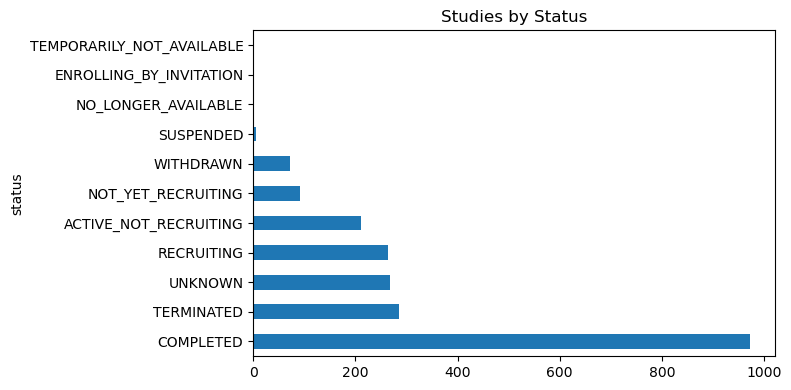

In [10]:
df['status'].value_counts().plot(kind='barh', figsize=(8, 4), title='Studies by Status')
plt.tight_layout()
plt.show()

## Phase distribution

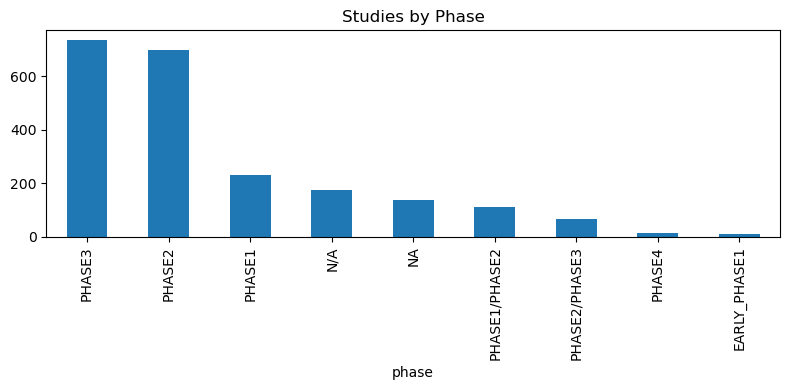

In [11]:
df['phase'].fillna('N/A').value_counts().plot(kind='bar', figsize=(8, 4), title='Studies by Phase')
plt.tight_layout()
plt.show()

## Enrollment histogram

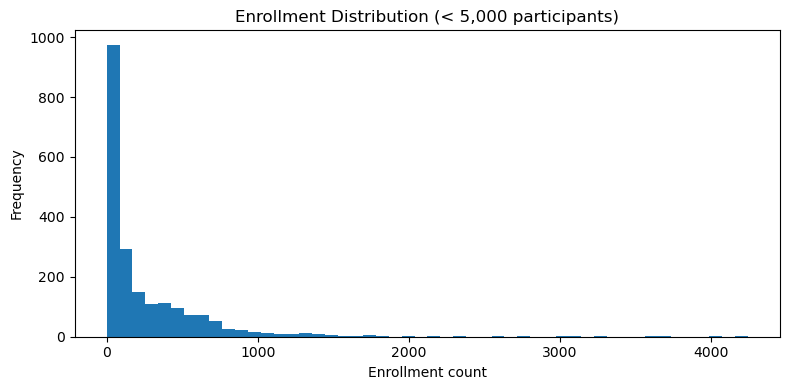

count     2078.000000
mean       270.782483
std        557.065632
min          0.000000
25%         32.000000
50%        100.000000
75%        363.750000
max      12400.000000
Name: enrollment, dtype: float64


In [12]:
enrollment = df['enrollment'].dropna()
enrollment[enrollment < 5000].plot(
    kind='hist', bins=50, figsize=(8, 4),
    title='Enrollment Distribution (< 5,000 participants)'
)
plt.xlabel('Enrollment count')
plt.tight_layout()
plt.show()
print(enrollment.describe())

## Trials opened per year

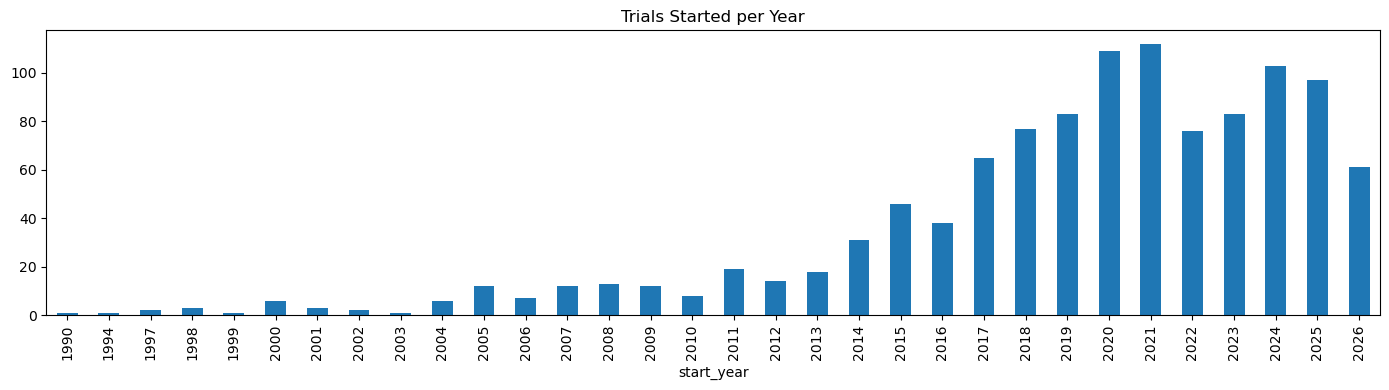

In [13]:
df['start_year'] = pd.to_datetime(df['start_date'], errors='coerce').dt.year
by_year = df['start_year'].dropna().astype(int).value_counts().sort_index()
by_year[by_year.index >= 1990].plot(
    kind='bar', figsize=(14, 4), title='Trials Started per Year'
)
plt.tight_layout()
plt.show()

## Geographic breakdown — trials by country

In [26]:
# Each study can have many locations — explode them out
locs = df['locations'].dropna().apply(json.loads)
study_countries = locs.apply(lambda loc_set: {loc.get('country') for loc in loc_set})
study_countries.head(10)
countries = set(study_countries.explode().dropna())
print(len(countries), "unique countries")
print(countries)
# countries.value_counts().head(20).plot(
#     kind='barh', figsize=(8, 6), title='Top 20 Countries by Trial Sites'
# )
# print(f"Trials conducted in {countries.nunique()} unique countries")
# plt.tight_layout()
# plt.show()

87 unique countries
{'Puerto Rico', 'Lebanon', 'Tunisia', 'United States', 'Finland', 'Hong Kong', 'Poland', 'Switzerland', 'Latvia', 'Chile', 'Saudi Arabia', 'Serbia', 'Canada', 'Taiwan', 'Brazil', 'Pakistan', 'Uruguay', 'Italy', 'Romania', 'Spain', 'Qatar', 'Ireland', 'Moldova', 'New Zealand', 'Guatemala', 'Portugal', 'Vietnam', 'Sweden', 'China', 'Argentina', 'Bosnia and Herzegovina', 'Cyprus', 'Austria', 'North Macedonia', 'Albania', 'Czechia', 'Australia', 'South Africa', 'Ukraine', 'Luxembourg', 'Ecuador', 'Japan', 'Russia', 'Indonesia', 'Croatia', 'Malaysia', 'Belarus', 'Slovenia', 'Colombia', 'Panama', 'Iceland', 'Mexico', 'Turkey (Türkiye)', 'Singapore', 'Kazakhstan', 'Costa Rica', 'Israel', 'Georgia', 'France', 'Dominican Republic', 'Venezuela', 'Estonia', 'Denmark', 'South Korea', 'Philippines', 'Greece', 'Norway', 'Slovakia', 'Morocco', 'Cuba', 'Germany', 'Guam', 'United Kingdom', 'Hungary', 'Thailand', 'India', 'Bulgaria', 'Lithuania', 'Jordan', 'Egypt', 'Federal Republic 

## Geographic breakdown — US trials by state

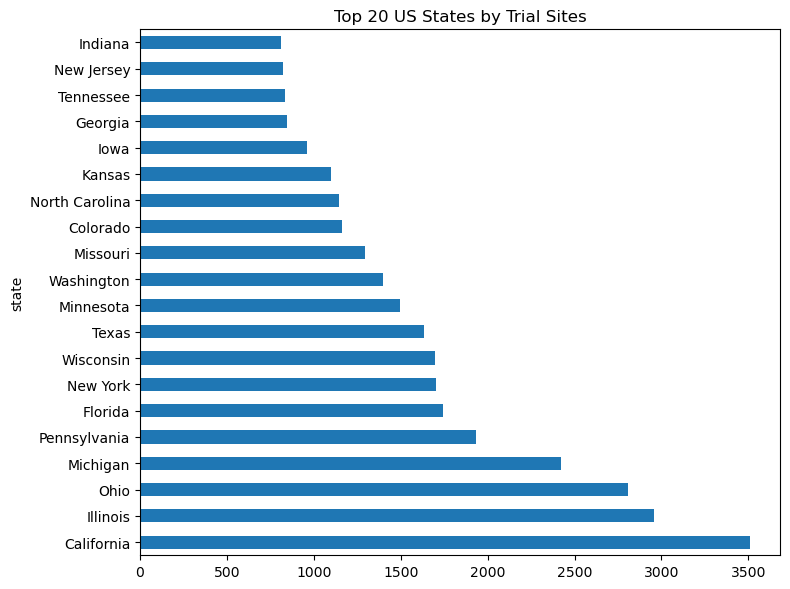

In [15]:
locs_df = pd.json_normalize(locs)
us = locs_df[locs_df['country'] == 'United States'].dropna(subset=['state'])
us['state'].value_counts().head(20).plot(
    kind='barh', figsize=(8, 6), title='Top 20 US States by Trial Sites'
)
plt.tight_layout()
plt.show()

## Sponsor class breakdown

{'Centre Hospitalier Intercommunal de Toulon La Seyne sur Mer', 'Tel-Aviv Sourasky Medical Center', 'CASI Pharmaceuticals, Inc.', 'Cancer Trials Ireland', 'Masonic Cancer Center, University of Minnesota', 'BerGenBio ASA', 'mAbxience Research S.L.', 'Clovis Oncology, Inc.', 'Addario Lung Cancer Medical Institute', 'National Institute of Cancerología', "Queen's University, Belfast", 'Suzhou Suncadia Biopharmaceuticals Co., Ltd.', 'Brown University', 'Istituto Scientifico H. San Raffaele', 'Imugene Limited', 'Barbara Ann Karmanos Cancer Institute', 'Genta Incorporated', 'Hansoh BioMedical R&D Company', 'Imperial College London', 'University of Manitoba', 'Bioven Sdn. Bhd.', 'Checkpoint Therapeutics, Inc.', 'Shanghai Huaota Biopharmaceutical Co., Ltd.', 'Oslo University Hospital', 'Dizal Pharmaceuticals', 'Second Affiliated Hospital of Nanchang University', 'National Hospital Organization Kinki-chuo Chest Medical Center', 'RemeGen Co., Ltd.', 'Spectrum Pharmaceuticals, Inc', 'Hellenic Onco

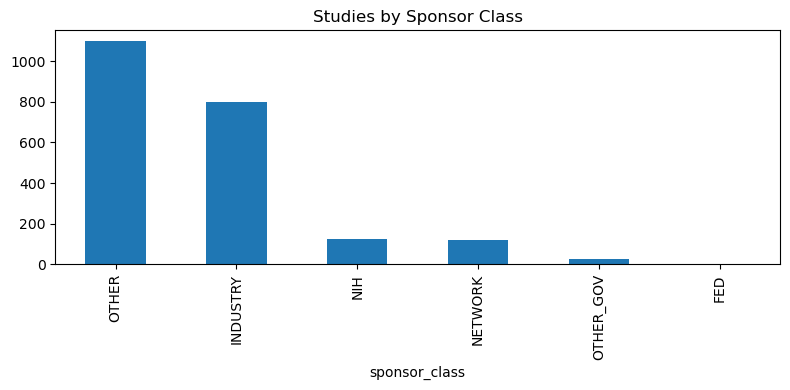

In [18]:
df['sponsor_class'].value_counts().plot(
    kind='bar', figsize=(8, 4), title='Studies by Sponsor Class'
)
print(set(df['sponsor']))
print("Number of unique sponsors: %s" % len(set(df['sponsor'])))
plt.tight_layout()
plt.show()